<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/revised_fair_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive



=== BASELINE XGBOOST ===
electricity_units_kwh MAE: 5.2128
power_outage_hours MAE: 1.1572
vulnerability_score MAE: 0.0632
Epoch 1, Loss: 40892.1509
Epoch 2, Loss: 9506.2242
Epoch 3, Loss: 4818.6877
Epoch 4, Loss: 3353.0778
Epoch 5, Loss: 2576.5627
Epoch 6, Loss: 2091.7334
Epoch 7, Loss: 1836.8057
Epoch 8, Loss: 1579.5285
Epoch 9, Loss: 1429.1487
Epoch 10, Loss: 1277.1110
Epoch 11, Loss: 1165.6796
Epoch 12, Loss: 964.2336
Epoch 13, Loss: 992.9820
Epoch 14, Loss: 946.0183
Epoch 15, Loss: 833.3173
Epoch 16, Loss: 755.2635
Epoch 17, Loss: 697.6614
Epoch 18, Loss: 649.1277
Epoch 19, Loss: 612.9612
Epoch 20, Loss: 610.3837
Epoch 21, Loss: 570.4613
Epoch 22, Loss: 541.3056
Epoch 23, Loss: 505.0681
Epoch 24, Loss: 477.9135
Epoch 25, Loss: 472.1931
Epoch 26, Loss: 477.8202
Epoch 27, Loss: 452.3205
Epoch 28, Loss: 444.4270
Epoch 29, Loss: 409.2444
Epoch 30, Loss: 416.9918

=== FAIR MODEL ===
electricity_units_kwh MAE: 5.4691
power_outage_hours MAE: 1.8771
vulnerability_score MAE: 1.1211

=== FA

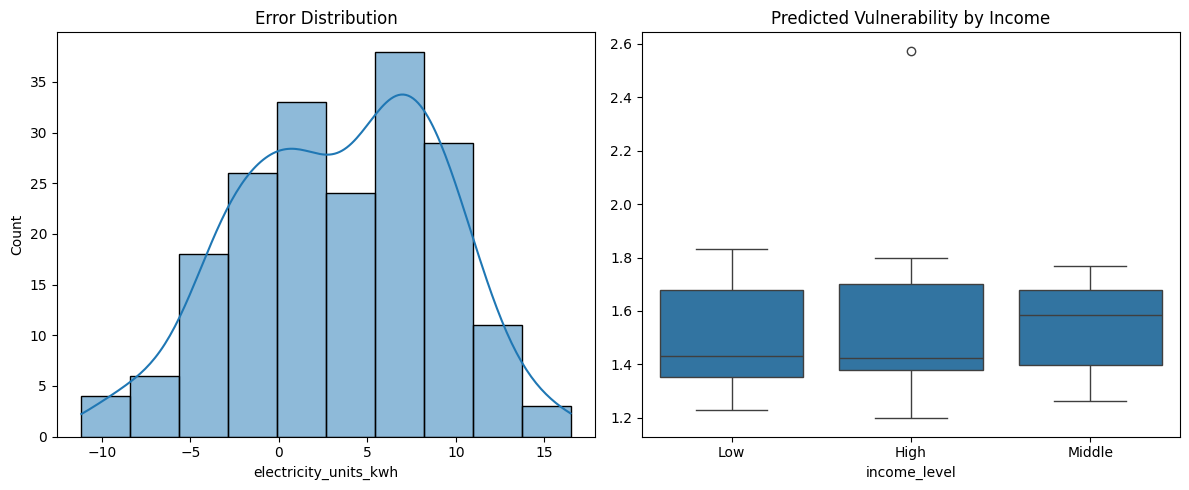

In [3]:
# ================= INSTALL =================
!pip install pandas numpy scikit-learn xgboost torch fairlearn matplotlib seaborn

# ================= IMPORTS =================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from fairlearn.metrics import demographic_parity_difference
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD DATA =================
df = pd.read_csv('/content/drive/MyDrive/Dataset/pakistan_household_electricity.csv')
df['date'] = pd.to_datetime(df['date'])

# ================= FEATURE ENGINEERING =================
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df = df.sort_values(['city', 'date'])

for lag in [1, 7]:
    df[f'consumption_lag_{lag}'] = df.groupby('city')['electricity_units_kwh'].shift(lag)
    df[f'outage_lag_{lag}'] = df.groupby('city')['power_outage_hours'].shift(lag)

df['consumption_roll_mean_7'] = df.groupby('city')['electricity_units_kwh'].transform(lambda x: x.rolling(7).mean())
df['temp_humidity_interaction'] = df['temperature_c'] * df['humidity_percent']

# Encoding
le_income = LabelEncoder()
le_city = LabelEncoder()

df['income_encoded'] = le_income.fit_transform(df['income_level'])
df['city_encoded'] = le_city.fit_transform(df['city'])

# ================= VULNERABILITY =================
df['norm_consumption'] = df['electricity_units_kwh'] / df['electricity_units_kwh'].max()
df['norm_outage'] = df['power_outage_hours'] / df['power_outage_hours'].max()

income_weight = {'Low':1.0,'Middle':0.6,'High':0.3}
df['income_weight'] = df['income_level'].map(income_weight)

df['vulnerability_score'] = (
    0.4*df['norm_consumption'] +
    0.4*df['norm_outage'] +
    0.2*df['income_weight']
)

# ================= SPLIT =================
feature_cols = [
    'temperature_c','humidity_percent','household_size','income_encoded',
    'city_encoded','year','month','day_of_week','is_weekend',
    'consumption_lag_1','consumption_lag_7','outage_lag_1','outage_lag_7',
    'consumption_roll_mean_7','temp_humidity_interaction'
]

target_cols = ['electricity_units_kwh','power_outage_hours','vulnerability_score']

df_model = df.dropna()

train = df_model[df_model['date'] < '2025-08-01']
test = df_model[df_model['date'] >= '2025-08-01']

X_train = train[feature_cols]
y_train = train[target_cols]
S_train = train['income_encoded']

X_test = test[feature_cols]
y_test = test[target_cols]
S_test = test['income_encoded']

# ================= BASELINE XGBOOST =================
xgb = MultiOutputRegressor(XGBRegressor(n_estimators=200))
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\n=== BASELINE XGBOOST ===")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:,i], y_pred_xgb[:,i])
    print(f"{col} MAE: {mae:.4f}")

# ================= DATASET =================
class EnergyDataset(Dataset):
    def __init__(self, X, y, s):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
        self.s = torch.tensor(s.values, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.s[idx]

train_loader = DataLoader(EnergyDataset(X_train, y_train, S_train), batch_size=64, shuffle=True)

# ================= GRADIENT REVERSAL =================
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

# ================= MODEL =================
class FairNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,128),
            nn.ReLU()
        )
        self.task_heads = nn.ModuleList([nn.Linear(128,1) for _ in range(3)])
        self.adv = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,3)
        )

    def forward(self, x, alpha=0):
        shared = self.shared(x)

        # Task predictions
        task_out = torch.cat([h(shared) for h in self.task_heads], dim=1)

        # Adversarial branch
        rev = GradReverse.apply(shared, alpha)
        adv_out = self.adv(rev)

        return task_out, adv_out

# ================= TRAIN =================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FairNet(len(feature_cols)).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
mse = nn.MSELoss()
ce = nn.CrossEntropyLoss()

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    alpha = min(0.1, epoch/20)  # gradual increase

    for Xb, yb, sb in train_loader:
        Xb, yb, sb = Xb.to(device), yb.to(device), sb.to(device)

        optimizer.zero_grad()

        task_pred, adv_pred = model(Xb, alpha)

        loss_task = mse(task_pred, yb)
        loss_adv = ce(adv_pred, sb)

        loss = loss_task + alpha * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ================= EVALUATION =================
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)
    y_pred_nn, _ = model(X_test_t)
    y_pred_nn = y_pred_nn.cpu().numpy()

print("\n=== FAIR MODEL ===")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:,i], y_pred_nn[:,i])
    print(f"{col} MAE: {mae:.4f}")

# ================= FAIRNESS =================
print("\n=== FAIRNESS COMPARISON ===")

for i, col in enumerate(target_cols):
    # Baseline
    base_bin = (y_pred_xgb[:,i] > y_pred_xgb[:,i].mean()).astype(int)
    fair_bin = (y_pred_nn[:,i] > y_pred_nn[:,i].mean()).astype(int)
    true_bin = (y_test.iloc[:,i] > y_test.iloc[:,i].mean()).astype(int)

    dp_base = demographic_parity_difference(true_bin, base_bin, sensitive_features=S_test)
    dp_fair = demographic_parity_difference(true_bin, fair_bin, sensitive_features=S_test)

    print(f"{col}")
    print(f"  XGB DPD : {dp_base:.4f}")
    print(f"  FairNN  : {dp_fair:.4f}")

# ================= PLOTS =================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_test['electricity_units_kwh'] - y_pred_nn[:,0], kde=True)
plt.title("Error Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=test['income_level'], y=y_pred_nn[:,2])
plt.title("Predicted Vulnerability by Income")

plt.tight_layout()
plt.savefig("final_results.png", dpi=300)
print("✅ Saved final_results.png")

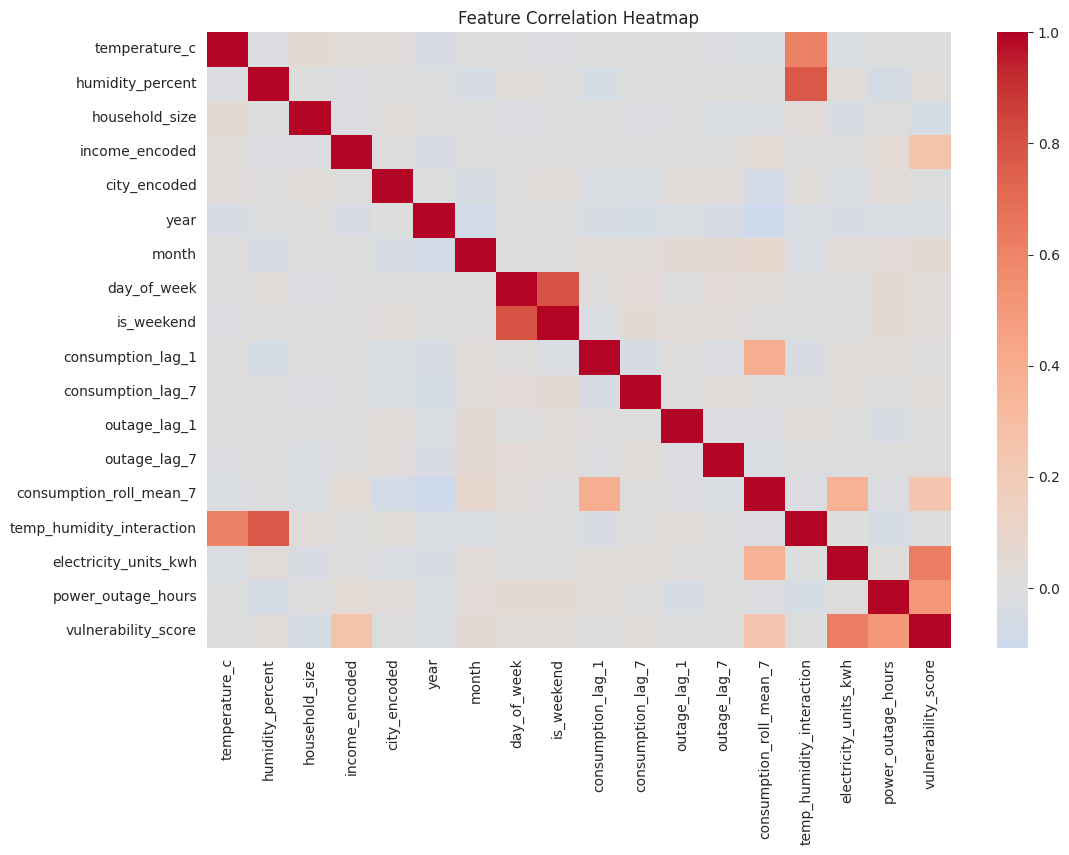

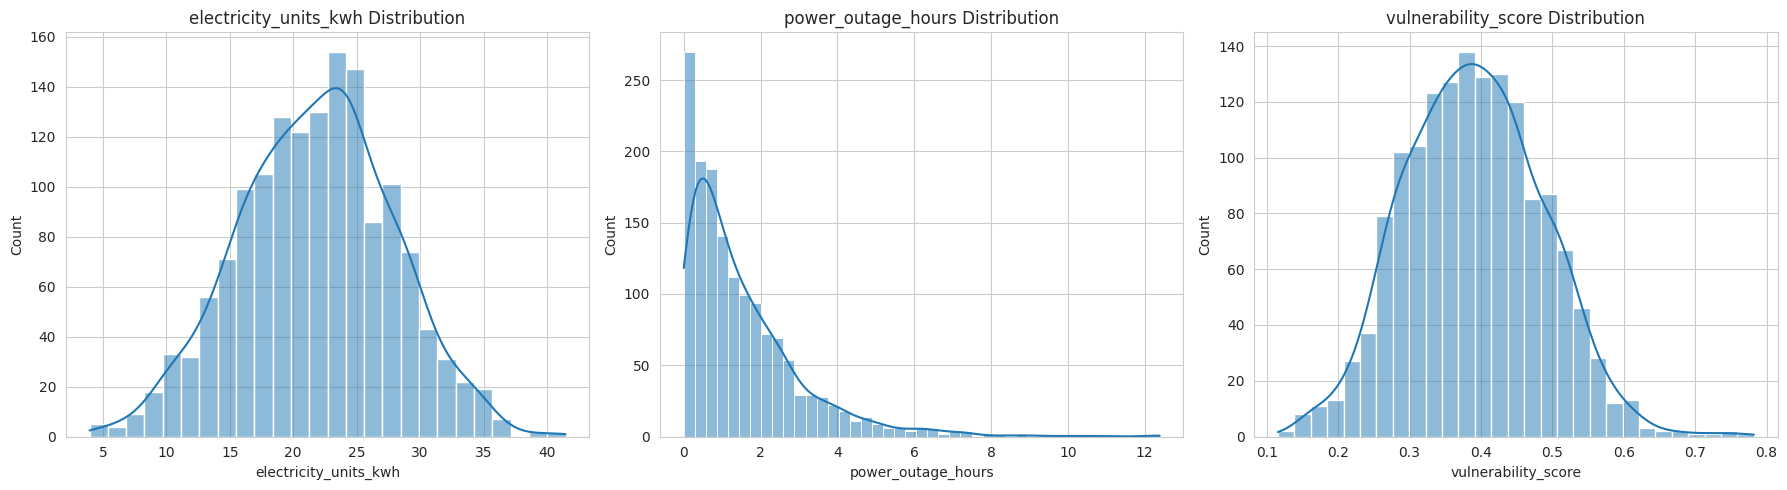

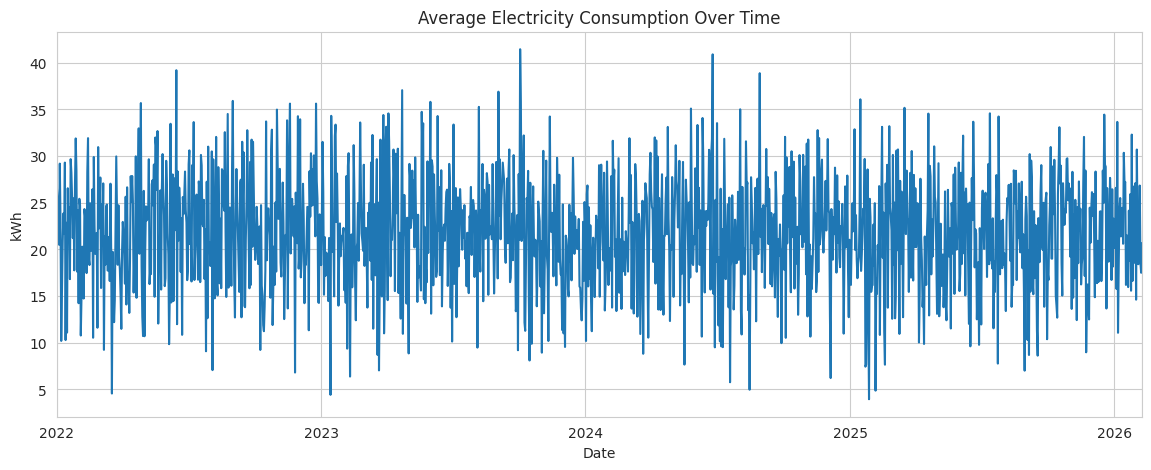

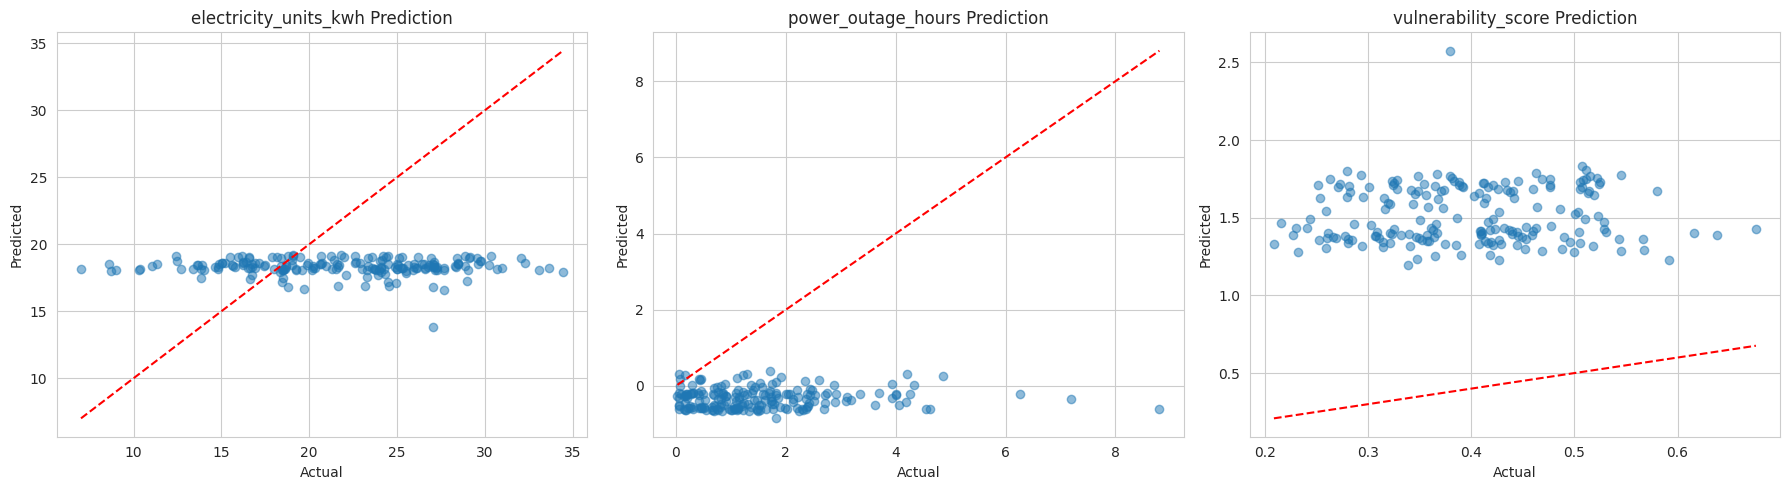

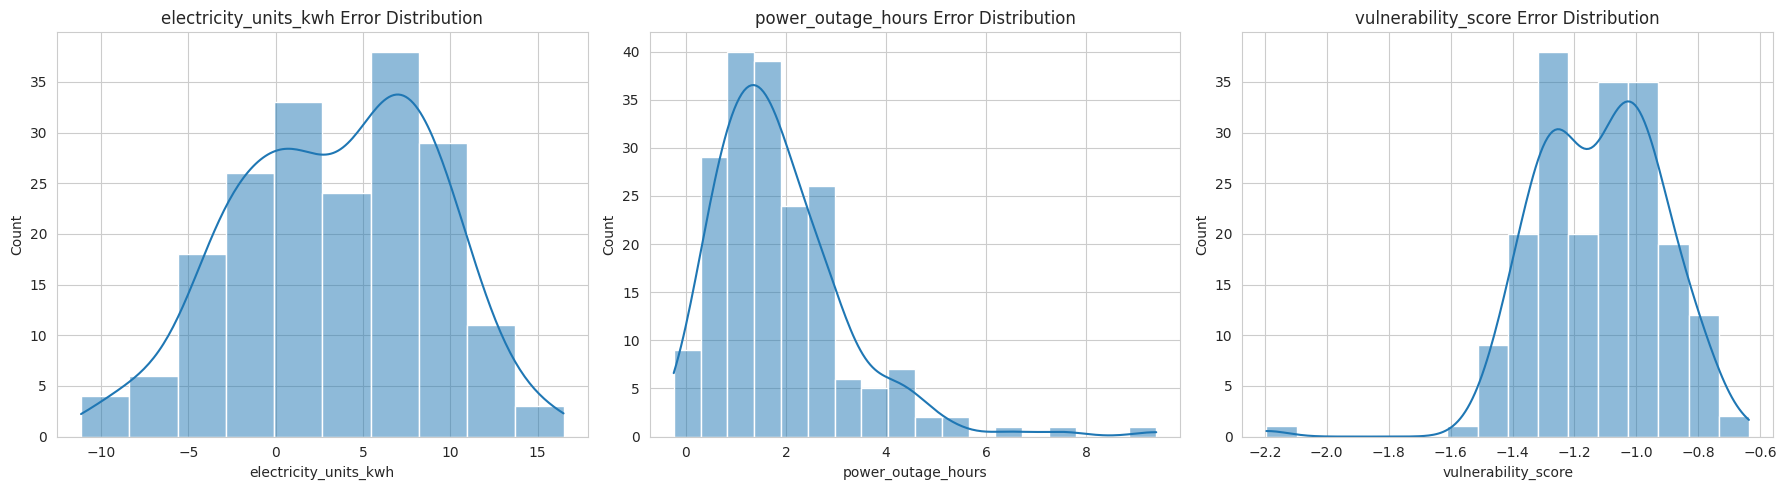

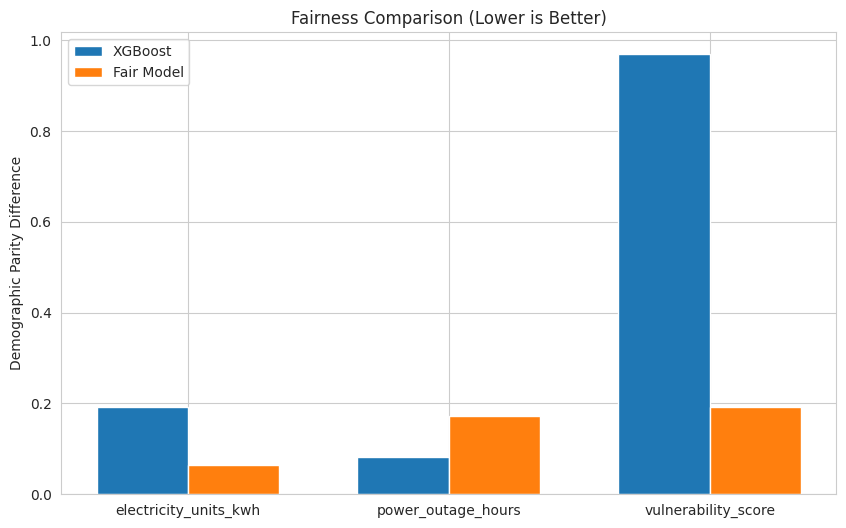

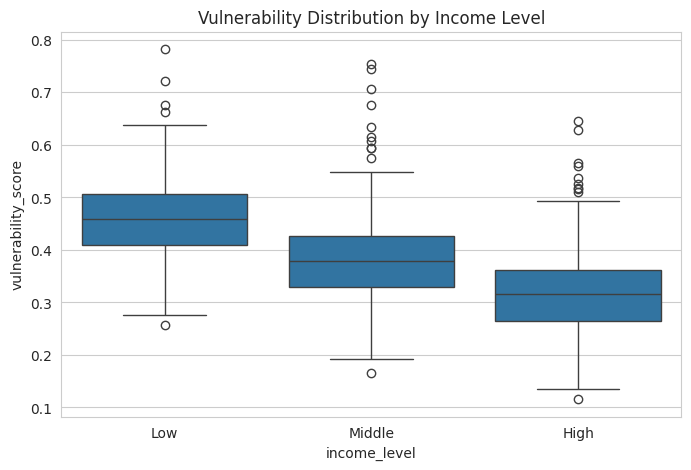

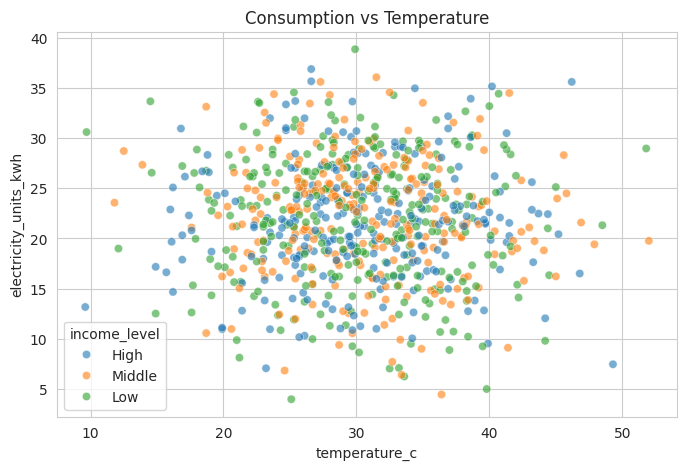

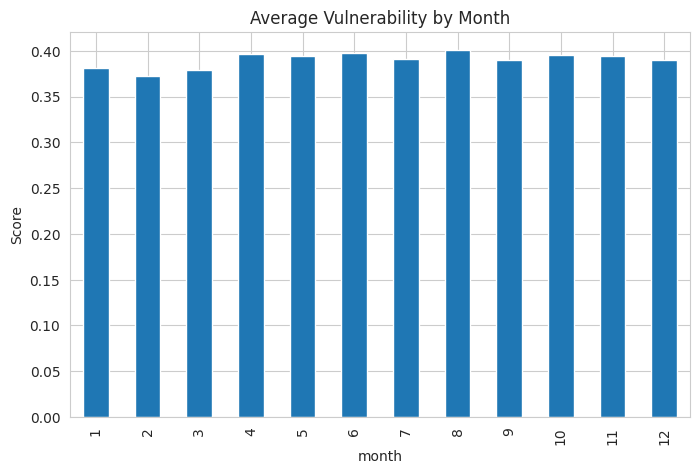

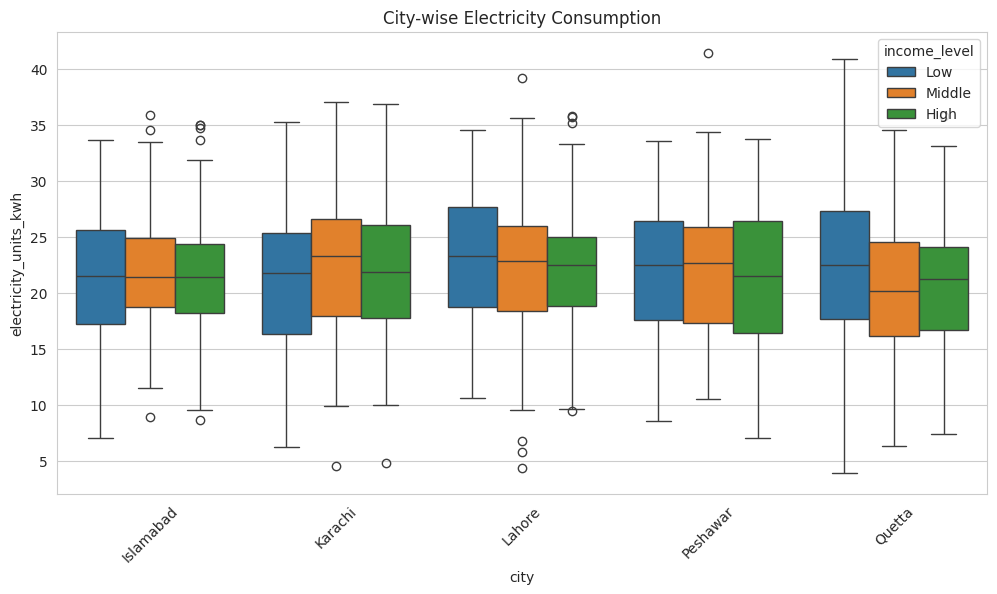

✅ All plots generated successfully!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# ================= 1. CORRELATION HEATMAP =================
plt.figure(figsize=(12,8))
corr = df[feature_cols + target_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.savefig("fig1_correlation_heatmap.png", dpi=300)
plt.show()

# ================= 2. TARGET DISTRIBUTIONS =================
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(target_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.savefig("fig2_target_distribution.png", dpi=300)
plt.show()

# ================= 3. TIME SERIES TREND =================
plt.figure(figsize=(14,5))
df.groupby('date')['electricity_units_kwh'].mean().plot()
plt.title("Average Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.savefig("fig3_timeseries.png", dpi=300)
plt.show()

# ================= 4. ACTUAL vs PREDICTED =================
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(target_cols):
    axes[i].scatter(y_test.iloc[:,i], y_pred_nn[:,i], alpha=0.5)
    axes[i].plot([y_test.iloc[:,i].min(), y_test.iloc[:,i].max()],
                 [y_test.iloc[:,i].min(), y_test.iloc[:,i].max()], 'r--')
    axes[i].set_title(f"{col} Prediction")
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.savefig("fig4_prediction_vs_actual.png", dpi=300)
plt.show()

# ================= 5. ERROR DISTRIBUTION =================
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(target_cols):
    errors = y_test.iloc[:,i] - y_pred_nn[:,i]
    sns.histplot(errors, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Error Distribution")

plt.tight_layout()
plt.savefig("fig5_error_distribution.png", dpi=300)
plt.show()

# ================= 6. FAIRNESS COMPARISON =================
dpd_xgb = []
dpd_fair = []

for i in range(3):
    base_bin = (y_pred_xgb[:,i] > y_pred_xgb[:,i].mean()).astype(int)
    fair_bin = (y_pred_nn[:,i] > y_pred_nn[:,i].mean()).astype(int)
    true_bin = (y_test.iloc[:,i] > y_test.iloc[:,i].mean()).astype(int)

    dp_base = demographic_parity_difference(true_bin, base_bin, sensitive_features=S_test)
    dp_fair_val = demographic_parity_difference(true_bin, fair_bin, sensitive_features=S_test)

    dpd_xgb.append(dp_base)
    dpd_fair.append(dp_fair_val)

x = np.arange(len(target_cols))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, dpd_xgb, width, label='XGBoost')
plt.bar(x + width/2, dpd_fair, width, label='Fair Model')

plt.xticks(x, target_cols)
plt.ylabel("Demographic Parity Difference")
plt.title("Fairness Comparison (Lower is Better)")
plt.legend()

plt.savefig("fig6_fairness_comparison.png", dpi=300)
plt.show()

# ================= 7. VULNERABILITY BY INCOME =================
plt.figure(figsize=(8,5))
sns.boxplot(x='income_level', y='vulnerability_score', data=df)
plt.title("Vulnerability Distribution by Income Level")
plt.savefig("fig7_vulnerability_income.png", dpi=300)
plt.show()

# ================= 8. CONSUMPTION vs TEMPERATURE =================
plt.figure(figsize=(8,5))
sns.scatterplot(x='temperature_c', y='electricity_units_kwh',
                hue='income_level', data=df.sample(800), alpha=0.6)
plt.title("Consumption vs Temperature")
plt.savefig("fig8_temp_vs_consumption.png", dpi=300)
plt.show()

# ================= 9. MONTHLY VULNERABILITY =================
monthly_vuln = df.groupby('month')['vulnerability_score'].mean()

plt.figure(figsize=(8,5))
monthly_vuln.plot(kind='bar')
plt.title("Average Vulnerability by Month")
plt.ylabel("Score")
plt.savefig("fig9_monthly_vulnerability.png", dpi=300)
plt.show()

# ================= 10. CITY LEVEL ANALYSIS =================
plt.figure(figsize=(12,6))
sns.boxplot(x='city', y='electricity_units_kwh', hue='income_level', data=df)
plt.xticks(rotation=45)
plt.title("City-wise Electricity Consumption")
plt.savefig("fig10_city_analysis.png", dpi=300)
plt.show()

print("✅ All plots generated successfully!")